#**Prophet Forecasting Model**

##**0) Objectives**

- Convert the cleaned daily sales series into Prophet format (ds, y) and validate a strict time-based split.
- Train a baseline Prophet model (trend + weekly + yearly seasonality) and evaluate test performance.
- Add holiday/event effects (Prophet holiday calendar) and evaluate whether accuracy improves.
- Interpret Prophet plots (forecast + components) to explain the demand drivers.

##**1) Setup & Drive Connection**

In [20]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Prophet for time series forecasting
from prophet import Prophet

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from prophet.plot import plot_plotly, plot_components_plotly

# Metrics for evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Colab Drive
from google.colab import drive
drive.mount('/content/drive')

# Data directory
DATA_DIR = "/content/drive/MyDrive/TimeSeries"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os

DATA_DIR = "/content/drive/MyDrive/TimeSeries"  # adjust if needed
print("Files in DATA_DIR:", os.listdir(DATA_DIR)[:25])

Files in DATA_DIR: ['holidays_events.csv', 'oil.csv', 'items.csv', 'stores.csv', 'transactions.csv', 'train.csv', 'largetrain.csv', 'cleaned_sales_data.csv']


##**2) Load Cleaned Daily Sales Data**

In [22]:
df = pd.read_csv(f"{DATA_DIR}/cleaned_sales_data.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df[["date", "total_sales"]].head()

,date,total_sales
0,2013-01-02,757.0
1,2013-01-03,534.0
2,2013-01-04,673.0
3,2013-01-05,898.0
4,2013-01-06,975.0


In [23]:
# Data validation (range + missing values)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Rows:", len(df))
print("Missing total_sales:", df["total_sales"].isna().sum())

Date range: 2013-01-02 → 2017-08-15
Rows: 1687
Missing total_sales: 0


**Insights**

- Prophet requires a continuous time column and a numeric target.
- Missing total_sales must be removed (Prophet cannot train on NaNs in y).

##**3) Prepare Prophet Dataset (ds, y)**

Prophet requires:
- ds: datetime
- y: numeric target

In [24]:
prophet_df = df[["date", "total_sales"]].copy()
prophet_df = prophet_df.rename(columns={"date": "ds", "total_sales": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

# Drop missing target values
prophet_df = prophet_df.dropna(subset=["y"]).reset_index(drop=True)

print(prophet_df.dtypes)
print("Missing values:", prophet_df.isna().sum().to_dict())
prophet_df.head()

ds    datetime64[ns]
y            float64
dtype: object
Missing values: {'ds': 0, 'y': 0}


,ds,y
0,2013-01-02,757.0
1,2013-01-03,534.0
2,2013-01-04,673.0
3,2013-01-05,898.0
4,2013-01-06,975.0


##**4) Time-based Train/Test Split**

We enforce the project test window:
- Train ≤ 2016-08-15
- Test 2016-08-16 → 2017-08-15

In [25]:
train_end  = "2016-08-15"
test_start = "2016-08-16"
test_end   = "2017-08-15"

train_df = prophet_df[prophet_df["ds"] <= train_end].copy()
test_df  = prophet_df[(prophet_df["ds"] >= test_start) & (prophet_df["ds"] <= test_end)].copy()

print("Train rows:", train_df.shape)
print("Test rows :", test_df.shape)
print("Train range:", train_df["ds"].min().date(), "→", train_df["ds"].max().date())
print("Test range :", test_df["ds"].min().date(), "→", test_df["ds"].max().date())

Train rows: (1322, 2)
Test rows : (365, 2)
Train range: 2013-01-02 → 2016-08-15
Test range : 2016-08-16 → 2017-08-15


**Insight**

This prevents leakage: the model only learns from the past, then predicts an unseen future year.

##**5) Baseline Prophet Model (Trend + Weekly + Yearly)**

In [26]:
m_base = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

m_base.fit(train_df)

**Insight**

The baseline Prophet model learns long-term growth (trend) and recurring weekly/yearly patterns without using external regressors.

##**6) Baseline Forecast (Test Period Only)**

In [27]:
future_base = m_base.make_future_dataframe(periods=len(test_df), freq="D")
fcst_base = m_base.predict(future_base)

# Filter prediction strictly to the test window
fcst_base_test = fcst_base[(fcst_base["ds"] >= test_start) & (fcst_base["ds"] <= test_end)].copy()
fcst_base_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
1322,2016-08-16,1428.659171,990.405483,1854.217080
1323,2016-08-17,1425.501453,1031.417096,1890.197929
1324,2016-08-18,1302.425801,872.760874,1756.730392
1325,2016-08-19,1373.688923,933.759072,1808.513690
1326,2016-08-20,1700.647446,1278.427990,2128.514483


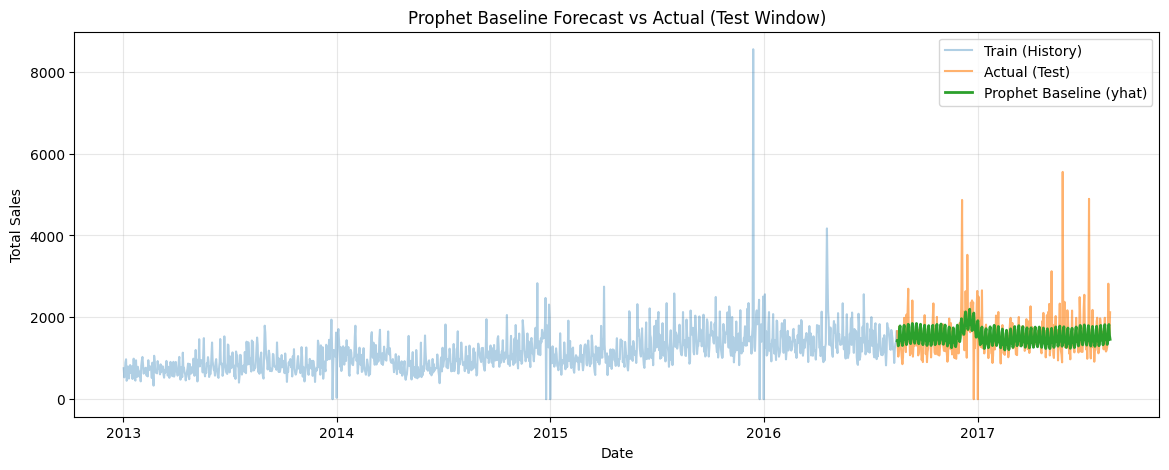

In [28]:
# Baseline forecast plot (Forecast vs Actual)
plt.figure(figsize=(14,5))
plt.plot(train_df["ds"], train_df["y"], label="Train (History)", alpha=0.35)
plt.plot(test_df["ds"], test_df["y"], label="Actual (Test)", alpha=0.6)
plt.plot(fcst_base_test["ds"], fcst_base_test["yhat"], label="Prophet Baseline (yhat)", linewidth=2)

plt.title("Prophet Baseline Forecast vs Actual (Test Window)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What it indicates**

- The baseline Prophet model follows the overall trend and seasonality well.
- Forecasts are smooth and stable, staying close to the average sales level.
- The model underestimates sharp spikes in the test period, especially extreme peaks.

**Conclusion**
The baseline Prophet captures general patterns accurately but produces conservative forecasts that miss short-term volatility.

##**7) Baseline Components (Trend, Weekly, Yearly)**

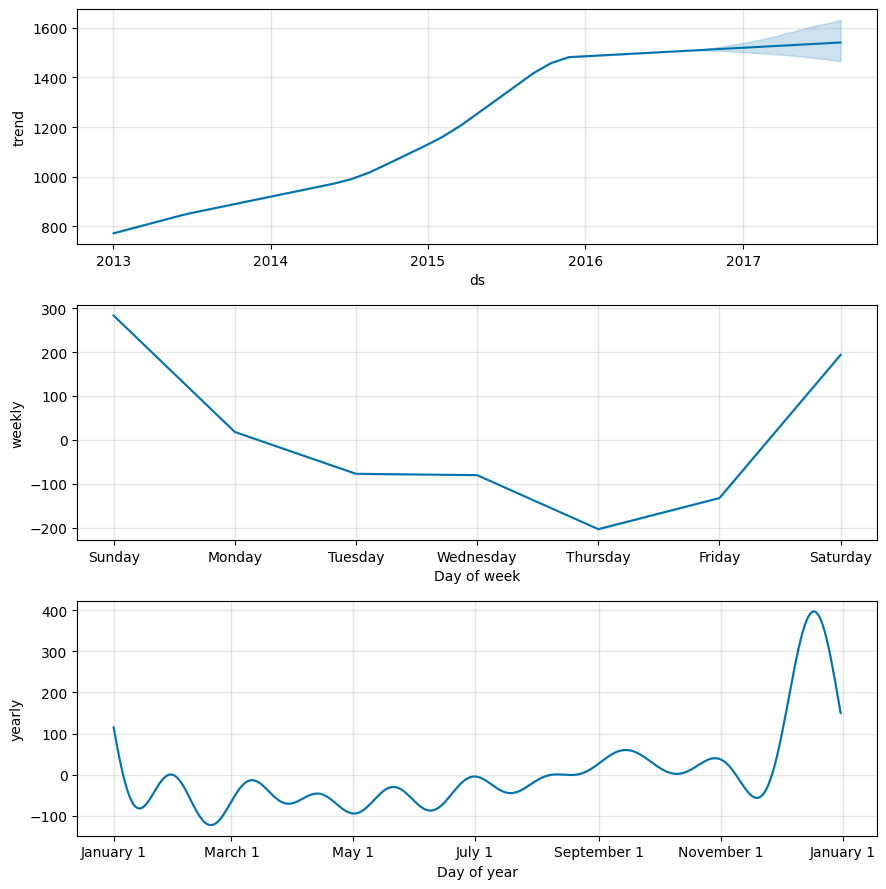

In [29]:
m_base.plot_components(fcst_base)
plt.show()

**Insights**

- Trend: long-term growth path. Changes in slope = acceleration/slowdown in demand.
- Weekly: values above 0 indicate above-average days; below 0 indicate weaker days.
- Yearly: repeating within-year pattern; end-of-year rises often signal holiday season effects.

##**8) Baseline Evaluation (MAE / RMSE / Bias)**

In [30]:
y_true = test_df["y"].values
y_pred_base = fcst_base_test["yhat"].values

base_mae  = mean_absolute_error(y_true, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_true, y_pred_base))
base_bias = (y_pred_base - y_true).mean()

print(f"Prophet Baseline MAE : {base_mae:.2f}")
print(f"Prophet Baseline RMSE: {base_rmse:.2f}")
print(f"Prophet Baseline Bias: {base_bias:.2f}")

Prophet Baseline MAE : 285.75
Prophet Baseline RMSE: 485.06
Prophet Baseline Bias: -20.38


**Insights**

- MAE (285.75) and RMSE (485.06) represent a significant improvement over a naive baseline (MAE: 429.57, from the ARIMA notebook), confirming that Prophet adds real predictive value beyond simply repeating yesterday's sales.
- Negative bias (-20.38) shows the model slightly underpredicts sales on average, particularly missing peak demand days.

**Conclusion:**

The baseline Prophet model provides stable, conservative forecasts but tends to miss peak demand. It already outperforms both the naive baseline and the ARIMA model (MAE: 343.42).

#**Prophet + Holidays (External Calendar)**

##**9) Prepare Holidays for Prophet**

Prophet expects:
- ds = holiday date
- holiday = label

- We use a **single “event” label** for all unique holiday/event dates to avoid duplicate-date merge effects.
- This gives Prophet a discrete signal that certain days behave differently than regular seasonal patterns.
- Using unique dates prevents double-counting an event day.

In [31]:
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

holiday_prophet = holidays[["date"]].drop_duplicates().copy()
holiday_prophet["holiday"] = "event"
holiday_prophet = holiday_prophet.rename(columns={"date": "ds"})

holiday_prophet.head()

,ds,holiday
0,2012-03-02,event
1,2012-04-01,event
2,2012-04-12,event
3,2012-04-14,event
4,2012-04-21,event


##**10) Fit Prophet with Holidays + Forecast**

In [32]:
m_holiday = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    holidays=holiday_prophet
)

m_holiday.fit(train_df)

future_h = m_holiday.make_future_dataframe(periods=len(test_df), freq="D")
fcst_h = m_holiday.predict(future_h)

fcst_h_test = fcst_h[(fcst_h["ds"] >= test_start) & (fcst_h["ds"] <= test_end)].copy()
fcst_h_test[["ds", "yhat"]].head()

,ds,yhat
1322,2016-08-16,1422.737460
1323,2016-08-17,1420.579343
1324,2016-08-18,1297.621844
1325,2016-08-19,1367.828617
1326,2016-08-20,1695.319099


##**11) Compare Baseline vs Holiday Model (Test Window)**

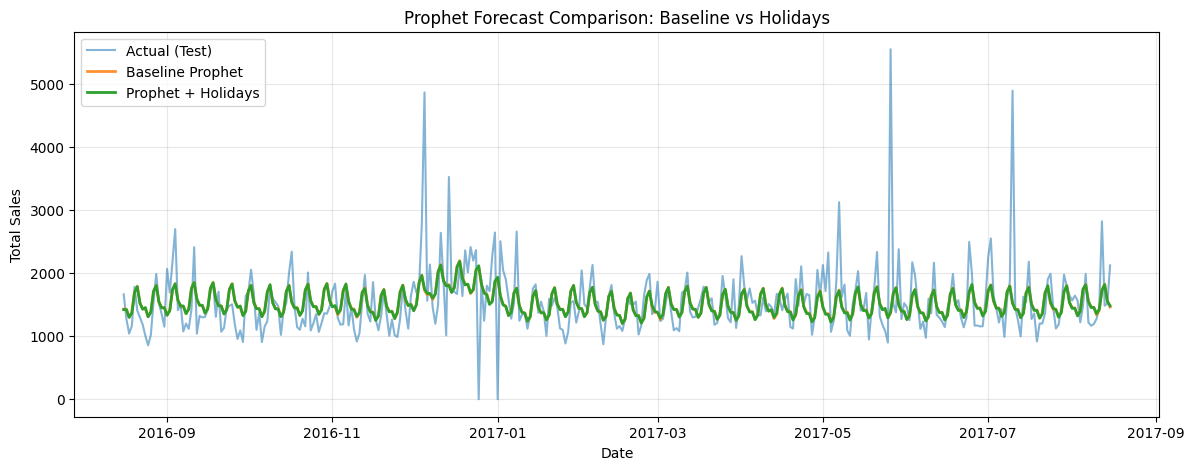

In [33]:
plt.figure(figsize=(14,5))
plt.plot(test_df["ds"], test_df["y"], label="Actual (Test)", alpha=0.55)
plt.plot(fcst_base_test["ds"], fcst_base_test["yhat"], label="Baseline Prophet", linewidth=2, alpha=0.85)
plt.plot(fcst_h_test["ds"], fcst_h_test["yhat"], label="Prophet + Holidays", linewidth=2)

plt.title("Prophet Forecast Comparison: Baseline vs Holidays")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insights**

- Both models capture the overall trend and weekly seasonality well.
- The **holiday model** only makes small adjustments and stays very close to the baseline
- Neither model captures extreme sales spikes, which are likely driven by promotions or outliers.

Holidays add limited value here; sales are mainly driven by regular seasonal patterns.

##**12) Holiday Model Evaluation (MAE / RMSE / Bias)**

In [34]:
y_pred_h = fcst_h_test["yhat"].values

h_mae  = mean_absolute_error(y_true, y_pred_h)
h_rmse = np.sqrt(mean_squared_error(y_true, y_pred_h))
h_bias = (y_pred_h - y_true).mean()

print(f"Prophet + Holidays MAE : {h_mae:.2f}")
print(f"Prophet + Holidays RMSE: {h_rmse:.2f}")
print(f"Prophet + Holidays Bias: {h_bias:.2f}")

Prophet + Holidays MAE : 285.28
Prophet + Holidays RMSE: 484.54
Prophet + Holidays Bias: -22.51


**Insights**

- MAE (285) and RMSE (485) indicate moderate forecast error.
- Negative bias (-22.5) shows the model slightly underpredicts sales on average.
- Overall, the holiday model performs reasonably but does not show a strong improvement.

##**13) Holiday Model Components**

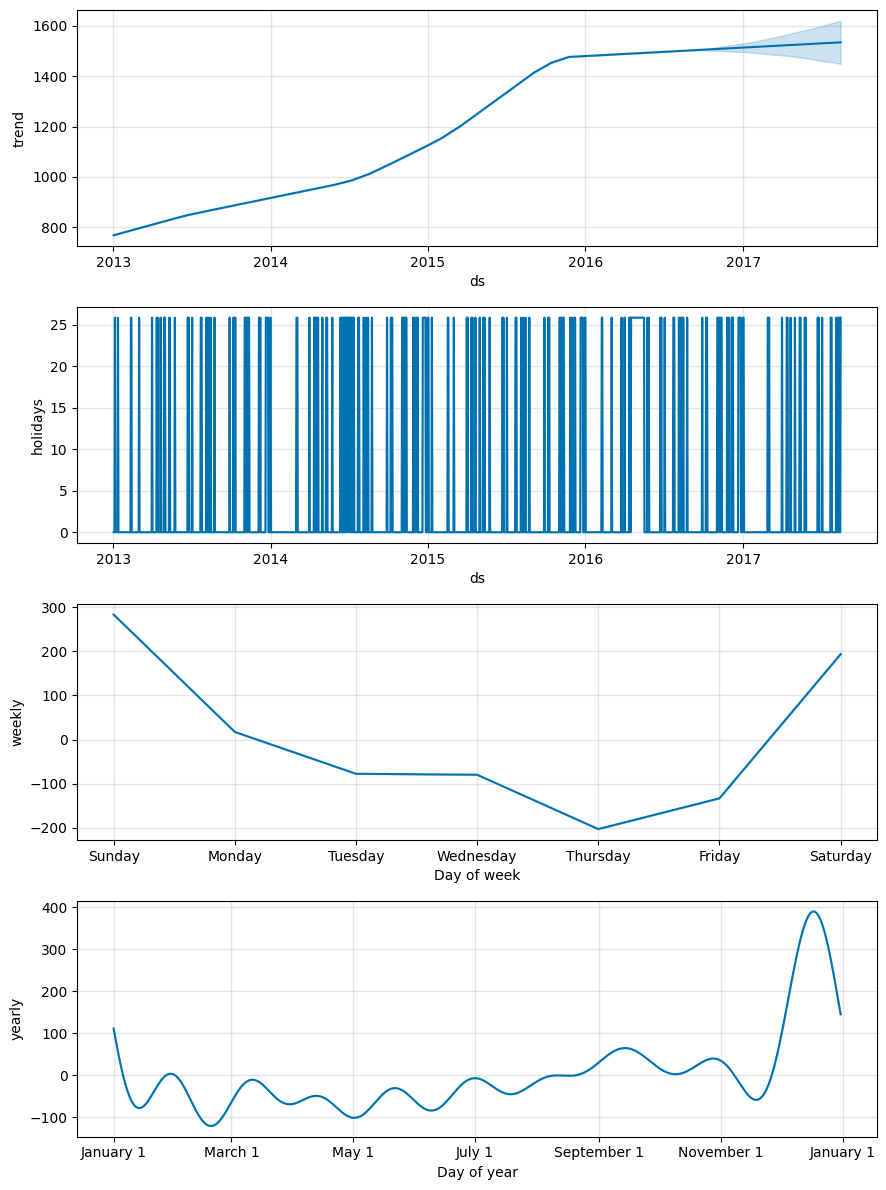

In [35]:
m_holiday.plot_components(fcst_h)
plt.show()

**Insights**

- **Trend:** Sales increase steadily over time, then level off toward the end.
- **Holidays:** Holiday effects are frequent but relatively small and noisy.
- **Weekly:** Strong weekly pattern — highest on weekends, weakest midweek.
- **Yearly:** Clear seasonal cycle with a noticeable peak toward year-end.

**Conclusion:** The model is mainly driven by trend and seasonality; holidays play a secondary role.

##**14) Final Prophet Comparison Table**

In [36]:
prophet_comparison = pd.DataFrame({
    "Model": ["Prophet Baseline", "Prophet + Holidays"],
    "MAE": [base_mae, h_mae],
    "RMSE": [base_rmse, h_rmse],
    "Bias": [base_bias, h_bias]
})

prophet_comparison

,Model,MAE,RMSE,Bias
0,Prophet Baseline,285.746054,485.062658,-20.377130
1,Prophet + Holidays,285.276207,484.542368,-22.507064


**Insights**

- MAE and RMSE are nearly identical for both models.
- Prophet + Holidays shows a *very small* improvement in error but a slightly larger negative bias.
- Overall performance is effectively the same.

**Conclusion**
Adding holidays does not meaningfully improve the forecast; the baseline Prophet model is sufficient.

#**Final Conclusion: Prophet Time Series Forecasting**

- Prophet effectively models daily retail sales by decomposing trend, weekly seasonality, yearly seasonality, and holidays.

- Both the baseline and holiday models produced stable forecasts that tracked overall sales well during the test period.

- Adding holidays resulted in only marginal improvements in MAE and RMSE, indicating limited additional value for this dataset. A possible enhancement would be to differentiate holiday types (e.g., "national_holiday", "earthquake", "transferred") rather than using a single "event" label, which may allow the model to learn distinct effects.

- Both models show a small negative bias, meaning they slightly underpredict peak sales and produce conservative forecasts.

- Prophet performs best for data with strong seasonality and gradual trend changes, offering reliable and interpretable results.

- Compared to the ARIMA/SARIMAX models, Prophet achieves lower MAE (285.8 vs. 316.8) and RMSE (485.1 vs. 497.7), while requiring significantly less manual configuration.

**Overall:**

The baseline Prophet model is sufficient; holiday effects play a minor role. Prophet provides the best balance of accuracy, simplicity, and interpretability among the models tested.